In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent.parent))
from regime_utils import read_csv, write_csv

In [2]:
#All daily series are resampled to weekly frequency using week-ending Friday values, taking the last available observation within each week.

vix = read_csv("vix.csv", parse_dates=["Date"])
vix = vix.set_index("Date").sort_index()

In [3]:
vix.drop('Volume', axis=1, inplace=True)

In [4]:
vix_weekly = (
    vix
    .resample("W-FRI")
    .last()
)

In [5]:
print(vix_weekly.head()) #sanity check 1

            Adj Close  Close   High    Low   Open
Date                                             
1994-01-07      10.96  10.96  12.14  10.00  11.47
1994-01-14      11.15  11.15  11.22  11.00  11.14
1994-01-21      11.09  11.09  11.21  10.90  10.90
1994-01-28       9.94   9.94  10.31   9.59   9.86
1994-02-04      15.25  15.25  15.63  10.21  10.71


In [6]:
write_csv(vix_weekly, "vix_weekly.csv")

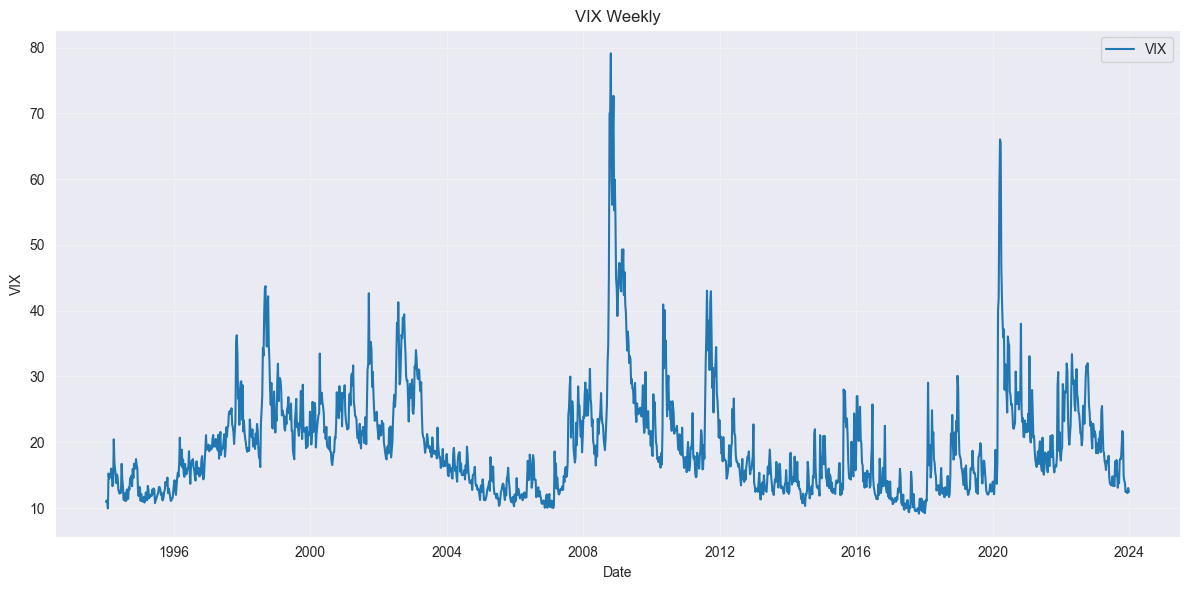

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(vix_weekly.index, vix_weekly["Close"], label="VIX", color="tab:blue")
plt.xlabel("Date")
plt.ylabel("VIX")
plt.title("VIX Weekly")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()